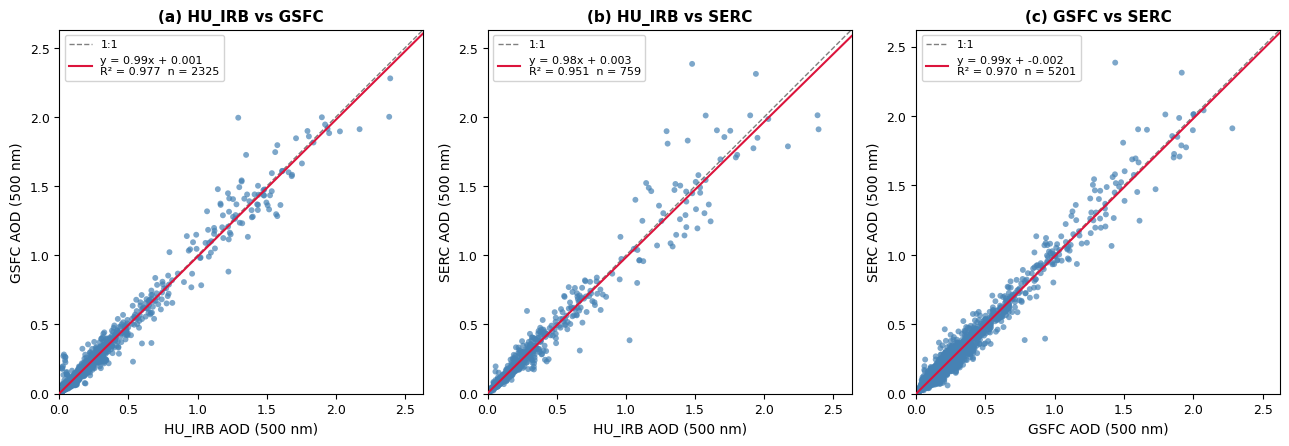

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Site display names
site_names = {"HU_IRB": "HU_IRB", "GSFC": "GSFC", "SERC": "SERC"}
pairs = [("HU_IRB", "GSFC"), ("HU_IRB", "SERC"), ("GSFC", "SERC")]
labels = ["(a)", "(b)", "(c)"]

# ── Load & hourly-average all three sites ────────────────────────────────────
hourly = {}
for site in ["HU_IRB", "GSFC", "SERC"]:
    df = pd.read_csv(f"../data/{site}_AOD500_preprocessed.csv", parse_dates=["datetime"])
    df = df.dropna(subset=["AOD_500nm"]).sort_values("datetime")
    df["hour"] = df["datetime"].dt.floor("1h")
    hourly[site] = (
        df.groupby("hour")["AOD_500nm"]
        .mean()
        .reset_index()
        .rename(columns={"hour": "datetime", "AOD_500nm": site})
    )

# ── Scatter plot 1×3 ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, (siteA, siteB), label in zip(axes, pairs, labels):
    merged = pd.merge(hourly[siteA], hourly[siteB], on="datetime", how="inner").dropna()
    x = merged[siteA].values
    y = merged[siteB].values

    ax.scatter(x, y, s=18, color="steelblue", alpha=0.7, edgecolors="none", zorder=2)

    # 1:1 line
    lim = max(x.max(), y.max()) * 1.1
    ax.plot([0, lim], [0, lim], "k--", linewidth=1, alpha=0.5, zorder=1, label="1:1")

    # Linear regression
    if len(x) >= 2:
        slope, intercept, r, _, _ = stats.linregress(x, y)
        x_fit = np.linspace(0, lim, 200)
        ax.plot(x_fit, slope * x_fit + intercept, color="crimson", linewidth=1.5, zorder=3,
                label=f"y = {slope:.2f}x + {intercept:.3f}\nR² = {r**2:.3f}  n = {len(x)}")

    ax.legend(fontsize=8, frameon=True, framealpha=0.85, loc="upper left")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel(f"{site_names[siteA]} AOD (500 nm)", fontsize=10)
    ax.set_ylabel(f"{site_names[siteB]} AOD (500 nm)", fontsize=10)
    ax.set_title(f"{label} {site_names[siteA]} vs {site_names[siteB]}", fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=9)
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.savefig("../data/AERONET_sites_scatter.png", dpi=300, bbox_inches="tight")
plt.show()


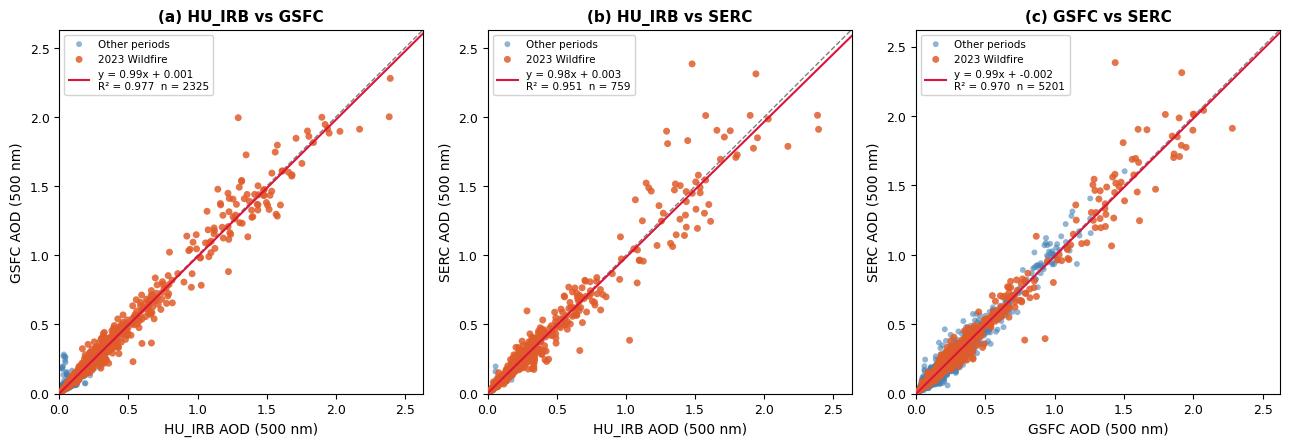

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

highlight_start = pd.Timestamp("2023-03-01")
highlight_end   = pd.Timestamp("2023-09-30")

site_names = {"HU_IRB": "HU_IRB", "GSFC": "GSFC", "SERC": "SERC"}
pairs  = [("HU_IRB", "GSFC"), ("HU_IRB", "SERC"), ("GSFC", "SERC")]
labels = ["(a)", "(b)", "(c)"]

# ── Load & hourly-average all three sites ────────────────────────────────────
hourly = {}
for site in ["HU_IRB", "GSFC", "SERC"]:
    df = pd.read_csv(f"../data/{site}_AOD500_preprocessed.csv", parse_dates=["datetime"])
    df = df.dropna(subset=["AOD_500nm"]).sort_values("datetime")
    df["hour"] = df["datetime"].dt.floor("1h")
    hourly[site] = (
        df.groupby("hour")["AOD_500nm"]
        .mean()
        .reset_index()
        .rename(columns={"hour": "datetime", "AOD_500nm": site})
    )

# ── Scatter plot 1×3 ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, (siteA, siteB), label in zip(axes, pairs, labels):
    merged = pd.merge(hourly[siteA], hourly[siteB], on="datetime", how="inner").dropna()

    mask_hl = (merged["datetime"] >= highlight_start) & (merged["datetime"] <= highlight_end)
    normal  = merged[~mask_hl]
    hl      = merged[mask_hl]

    x_n, y_n = normal[siteA].values, normal[siteB].values
    x_h, y_h = hl[siteA].values,     hl[siteB].values

    ax.scatter(x_n, y_n, s=18, color="steelblue", alpha=0.6, edgecolors="none", zorder=2, label="Other periods")
    ax.scatter(x_h, y_h, s=25, color="#e05c2a",   alpha=0.85, edgecolors="none", zorder=3, label="2023 Wildfire")

    # 1:1 line
    x_all, y_all = merged[siteA].values, merged[siteB].values
    lim = max(x_all.max(), y_all.max()) * 1.1
    ax.plot([0, lim], [0, lim], "k--", linewidth=1, alpha=0.5, zorder=1)

    # Linear regression on all points
    if len(x_all) >= 2:
        slope, intercept, r, _, _ = stats.linregress(x_all, y_all)
        x_fit = np.linspace(0, lim, 200)
        ax.plot(x_fit, slope * x_fit + intercept, color="crimson", linewidth=1.5, zorder=4,
                label=f"y = {slope:.2f}x + {intercept:.3f}\nR² = {r**2:.3f}  n = {len(x_all)}")

    ax.legend(fontsize=7.5, frameon=True, framealpha=0.85, loc="upper left")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel(f"{site_names[siteA]} AOD (500 nm)", fontsize=10)
    ax.set_ylabel(f"{site_names[siteB]} AOD (500 nm)", fontsize=10)
    ax.set_title(f"{label} {site_names[siteA]} vs {site_names[siteB]}", fontsize=11, fontweight="bold")
    ax.tick_params(labelsize=9)
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
# plt.savefig("../data/AERONET_sites_scatter.png", dpi=300, bbox_inches="tight")
plt.show()
